# **Trabajo Práctico N°2: Clasificación de Intenciones**
### **Ciencia de Datos 2026 - UTN Santa Fe**

**Objetivo:** Desarrollar un modelo capaz de clasificar intenciones a partir de consultas en inglés utilizando el dataset `intent.csv` (77 categorías).

---

## **1. Importación de Librerías y Configuración**
En esta celda importamos todas las dependencias necesarias para las distintas etapas del proyecto: manipulación de datos, graficación, procesamiento del lenguaje natural (NLP), aprendizaje automático tradicional, balanceo de clases y aprendizaje profundo (PyTorch).

In [7]:
# --- Ciencia de Datos & Gráficos ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Procesamiento de Lenguaje Natural (NLP) ---
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
import spacy
import gensim
from gensim.models import Word2Vec
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sentence_transformers import SentenceTransformer

# --- Machine Learning Tradicional & Evaluación ---
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# --- Balanceo de Clases ---
# from imblearn.over_sampling import SMOTE

# --- Deep Learning (PyTorch) ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# --- Configuraciones de estilo para gráficos ---
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# --- Descarga de recursos necesarios para NLTK ---
nltk.download('punkt_tab', quiet=True)   # ← 'punkt_tab' en NLTK >= 3.9
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)


print("¡Librerías importadas y configuradas con éxito!")
print(f"PyTorch versión: {torch.__version__}")


¡Librerías importadas y configuradas con éxito!
PyTorch versión: 2.12.0+cpu


In [ ]:
# Inicializar herramientas NLP una sola vez (eficiencia)
_lemmatizer = WordNetLemmatizer()
_stop_words = set(stopwords.words('english'))

def get_wordnet_pos(treebank_tag: str) -> str:
    """Convierte POS tag de NLTK (Treebank) a formato WordNet para lemmatización.
    """
    if treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default: sustantivo


In [19]:
# Carga del dataset
df = pd.read_csv("./Documentos/intent.csv")

In [20]:
def clean_text(text: str) -> str:
    """
    Preprocesa texto en inglés para vectorización con TF-IDF:
      1. Lowercase
      2. Eliminación de URLs
      3. Eliminación de caracteres no alfanuméricos
      4. Tokenización
      5. POS tagging (para lemmatización precisa de verbos y sustantivos)
      6. Eliminación de stopwords y tokens cortos (< 2 chars)
      7. Lemmatización con POS (varía lemmatización dependiendo del tipo de palabra)

    NO usar con SBERT/embeddings (rompe el contexto semántico).
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    tokens = [
        _lemmatizer.lemmatize(token, pos=get_wordnet_pos(tag))
        for token, tag in pos_tags
        if token not in _stop_words and len(token) > 1
    ]
    return ' '.join(tokens)

# --- Aplicar preprocesamiento (solo para TF-IDF) ---
df['text_clean'] = df['text'].apply(clean_text)

# Verificación rápida
print("Original :", df['text'].iloc[0])
print("Limpio   :", df['text_clean'].iloc[0])

Original : I am still waiting on my card?
Limpio   : still wait card


In [21]:
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

Dimensiones del dataset: 13083 filas x 3 columnas


In [22]:
print(f"\nPrimeras filas:")
df.head()


Primeras filas:


,text,category,text_clean
0,I am still waiting on my card?,card_arrival,still wait card
1,What can I do if my card still hasn't arrived ...,card_arrival,card still hasnt arrive week
2,I have been waiting over a week. Is the card s...,card_arrival,wait week card still come
3,Can I track my card while it is in the process...,card_arrival,track card process delivery
4,"How do I know if I will get my card, or if it ...",card_arrival,know get card lose


In [23]:
# Información general: tipos de datos y memoria
print("=== Información del DataFrame ===")
df.info()
print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())
print(f"\n=== Filas duplicadas: {df.duplicated().sum()} ===")

=== Información del DataFrame ===
<class 'pandas.DataFrame'>
RangeIndex: 13083 entries, 0 to 13082
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        13083 non-null  str  
 1   category    13083 non-null  str  
 2   text_clean  13083 non-null  str  
dtypes: str(3)
memory usage: 306.8 KB

=== Valores nulos por columna ===
text          0
category      0
text_clean    0
dtype: int64

=== Filas duplicadas: 0 ===


In [24]:
# --- Conteo y porcentaje por clase ---
class_counts = df["category"].value_counts()
class_pcts   = df["category"].value_counts(normalize=True).mul(100).round(2)

class_summary = pd.DataFrame({
    "Cantidad": class_counts,
    "Porcentaje (%)": class_pcts
})

print(f"Número de categorías únicas: {df['category'].nunique()}")
print(f"\nMínimo de muestras por clase : {class_counts.min()} — Clase: '{class_counts.idxmin()}'")
print(f"Máximo de muestras por clase : {class_counts.max()} — Clase: '{class_counts.idxmax()}'")
print(f"Promedio de muestras por clase: {class_counts.mean():.1f}")
print()


Número de categorías únicas: 77

Mínimo de muestras por clase : 75 — Clase: 'contactless_not_working'
Máximo de muestras por clase : 227 — Clase: 'card_payment_fee_charged'
Promedio de muestras por clase: 169.9



In [25]:
class_summary

,Cantidad,Porcentaje (%)
category,,
card_payment_fee_charged,227,1.74
direct_debit_payment_not_recognised,222,1.70
balance_not_updated_after_cheque_or_cash_deposit,221,1.69
wrong_amount_of_cash_received,220,1.68
cash_withdrawal_charge,217,1.66
...,...,...
lost_or_stolen_card,122,0.93
card_swallowed,101,0.77
card_acceptance,99,0.76


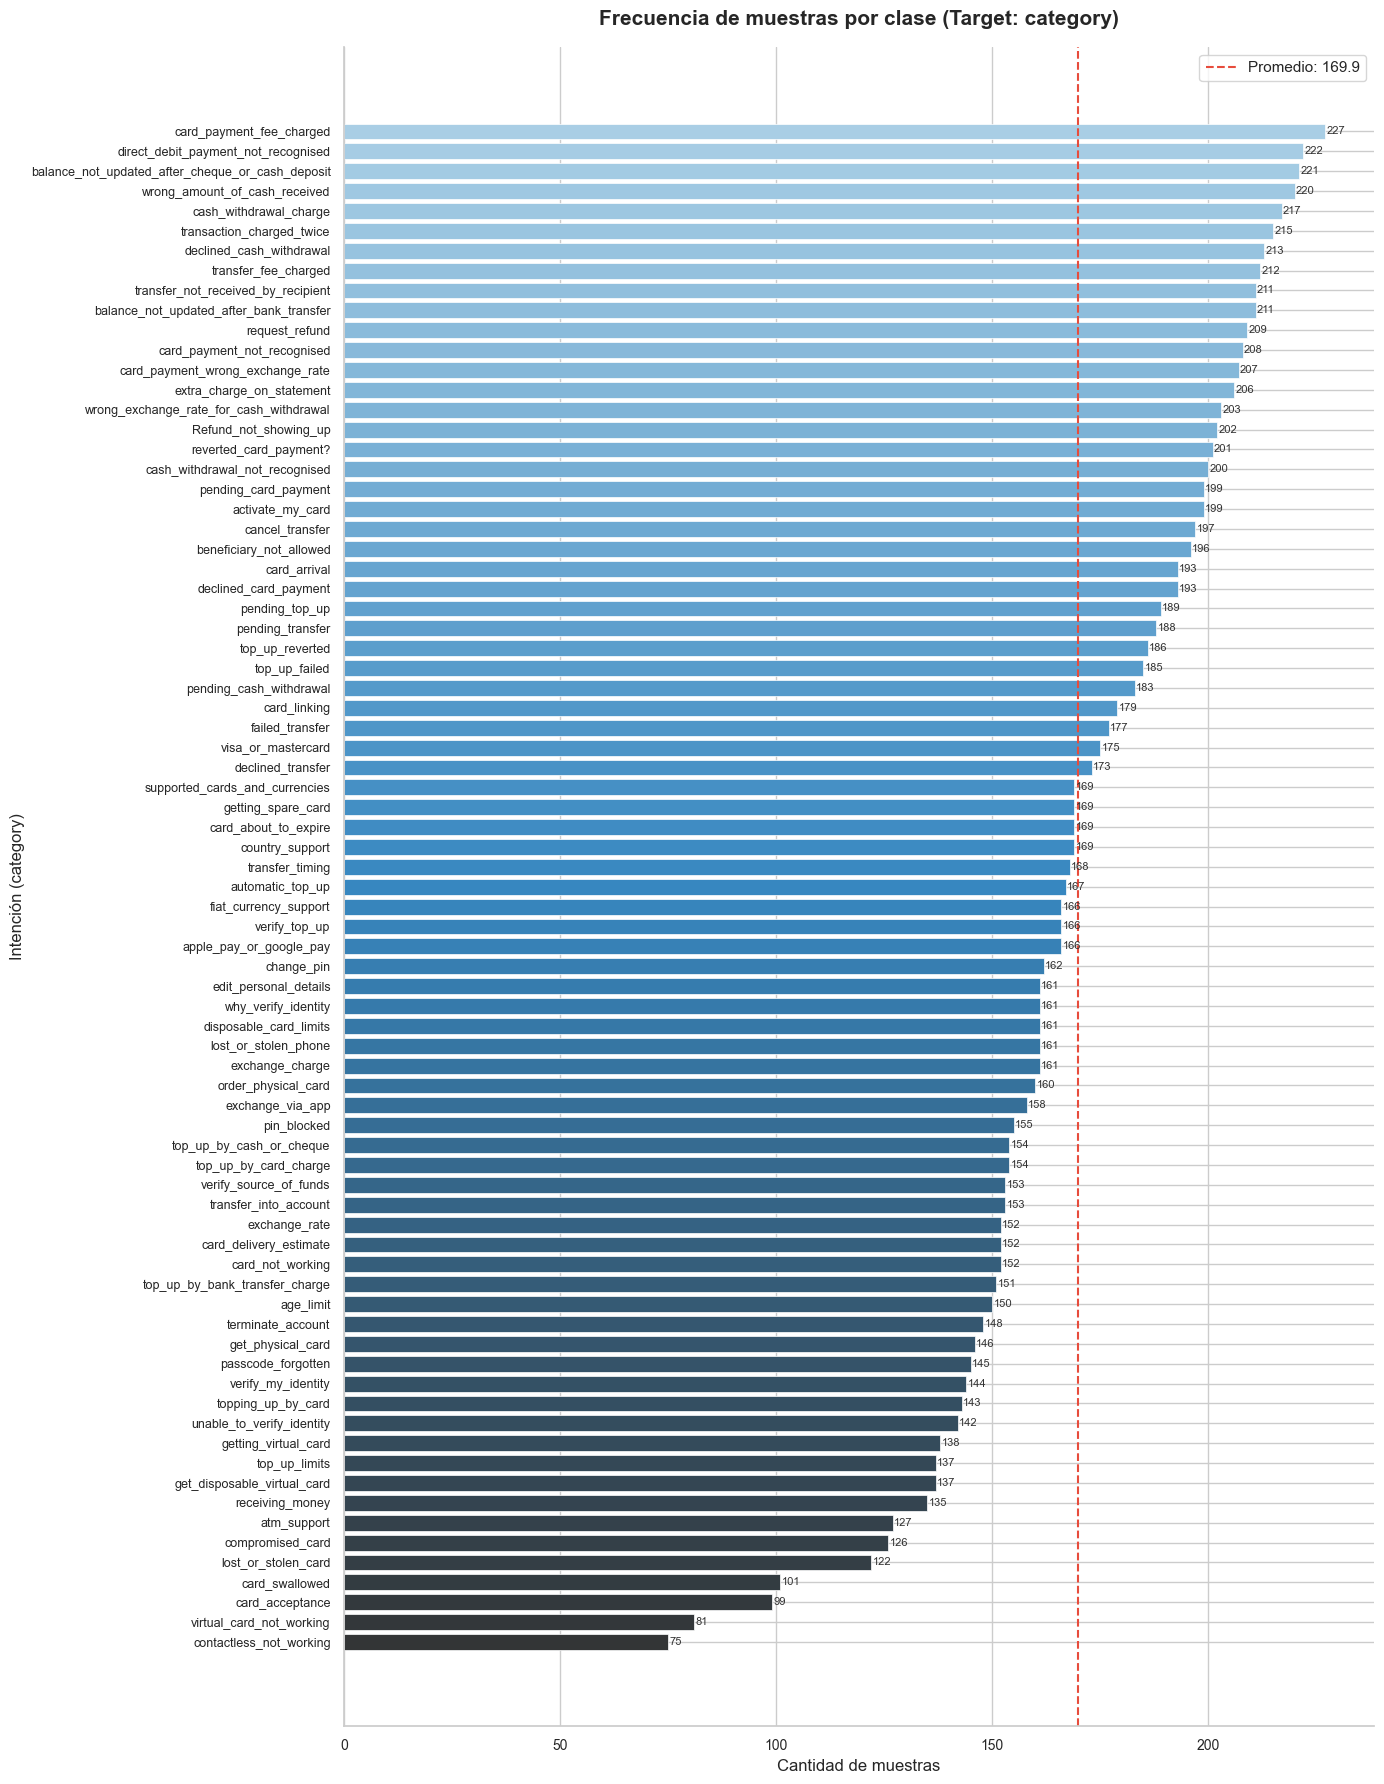

In [26]:
# --- Histograma de frecuencia por clase (ordenado de mayor a menor) ---
fig, ax = plt.subplots(figsize=(14, 18))

# Paleta de colores degradada por frecuencia
palette = sns.color_palette("Blues_d", n_colors=len(class_counts))

bars = ax.barh(
    class_counts.index,
    class_counts.values,
    color=palette,
    edgecolor="white",
    linewidth=0.5
)

# Línea del promedio
avg = class_counts.mean()
ax.axvline(avg, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Promedio: {avg:.1f}")

# Etiquetas de cantidad al final de cada barra
for bar, count in zip(bars, class_counts.values):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center", ha="left",
        fontsize=8, color="#333333"
    )

ax.set_title("Frecuencia de muestras por clase (Target: category)", fontsize=15, fontweight="bold", pad=16)
ax.set_xlabel("Cantidad de muestras", fontsize=12)
ax.set_ylabel("Intención (category)", fontsize=12)
ax.invert_yaxis()   # la clase más frecuente arriba
ax.legend(fontsize=11)
ax.tick_params(axis="y", labelsize=9)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()


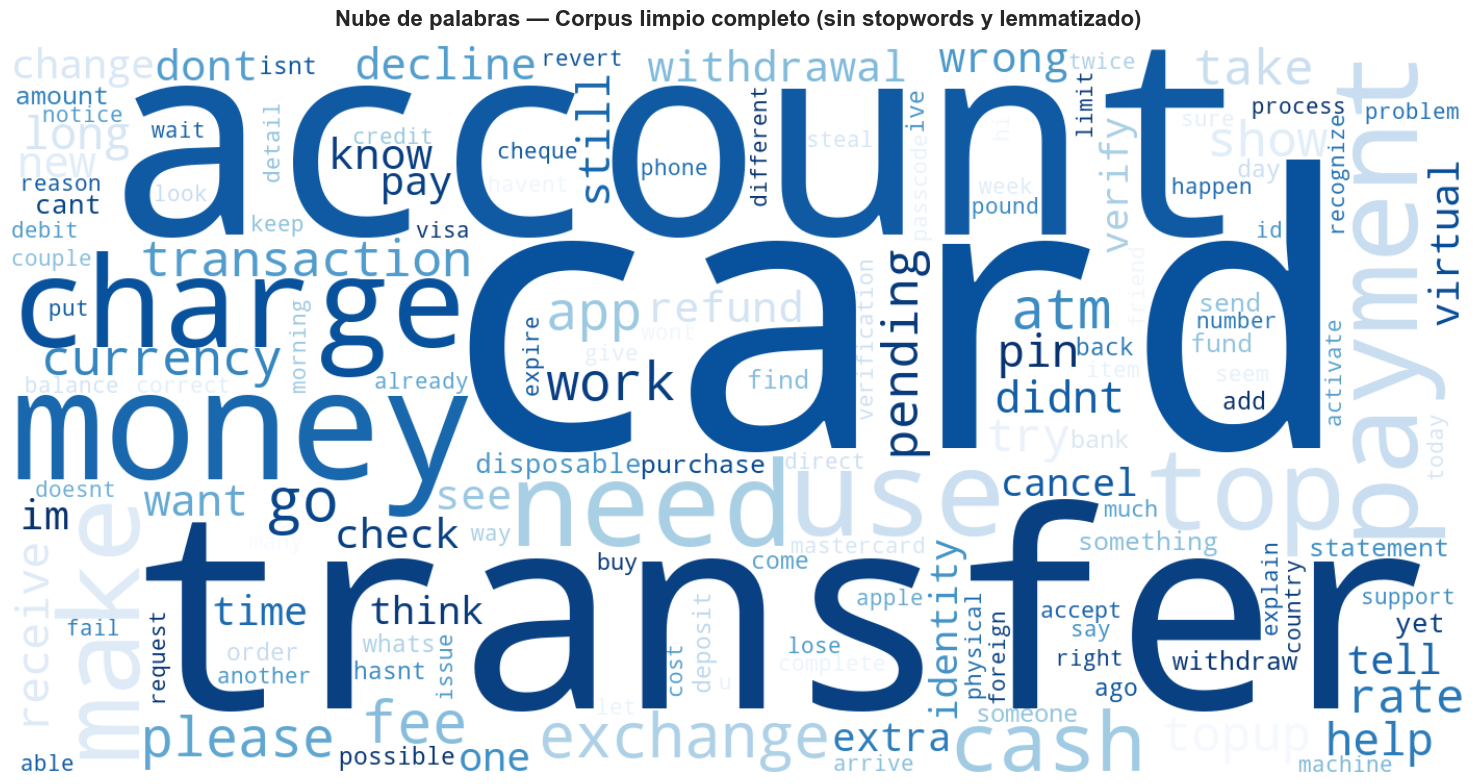

In [30]:
# Todo el texto cleaned del corpus unido en un solo string
corpus_text = " ".join(df["text_clean"].astype(str).tolist())

wc_global = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="Blues",
    max_words=150,
    collocations=False,   # evita repetir bigramas
    contour_color="steelblue",
    contour_width=1
).generate(corpus_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc_global, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — Corpus limpio completo (sin stopwords y lemmatizado)", fontsize=16, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()


In [31]:
# Crear columnas de longitud sobre el texto crudo
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df["char_count"] = df["text"].astype(str).apply(len)

print("=== Estadísticas de longitud ===")
print(df[["word_count", "char_count"]].describe().round(2))


=== Estadísticas de longitud ===
       word_count  char_count
count    13083.00    13083.00
mean        11.71       58.24
std          7.64       39.56
min          2.00       13.00
25%          7.00       36.00
50%         10.00       46.00
75%         13.00       63.00
max         79.00      433.00


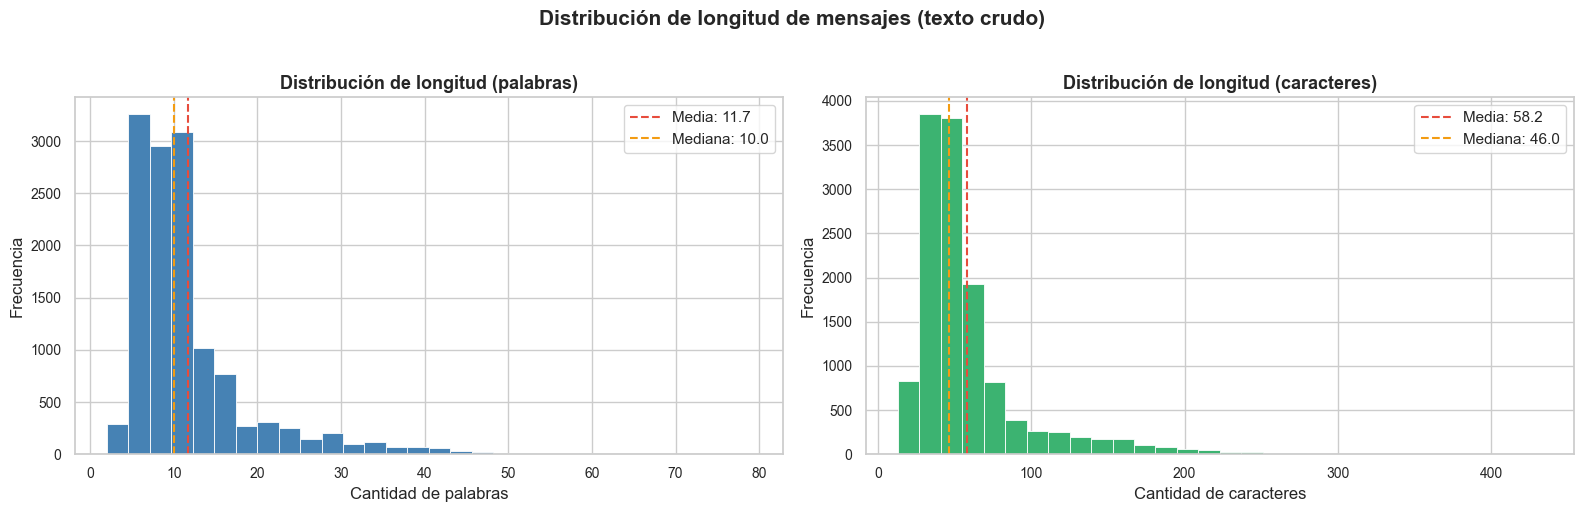

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Distribución en palabras ---
axes[0].hist(df["word_count"], bins=30, color="steelblue", edgecolor="white", linewidth=0.6)
axes[0].axvline(df["word_count"].mean(),   color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Media: {df['word_count'].mean():.1f}")
axes[0].axvline(df["word_count"].median(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mediana: {df['word_count'].median():.1f}")
axes[0].set_title("Distribución de longitud (palabras)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Cantidad de palabras")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# --- Distribución en caracteres ---
axes[1].hist(df["char_count"], bins=30, color="mediumseagreen", edgecolor="white", linewidth=0.6)
axes[1].axvline(df["char_count"].mean(),   color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Media: {df['char_count'].mean():.1f}")
axes[1].axvline(df["char_count"].median(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mediana: {df['char_count'].median():.1f}")
axes[1].set_title("Distribución de longitud (caracteres)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Cantidad de caracteres")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.suptitle("Distribución de longitud de mensajes (texto crudo)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


C:\Users\Gonza Gaitan\AppData\Local\Temp\ipykernel_22580\1844427921.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


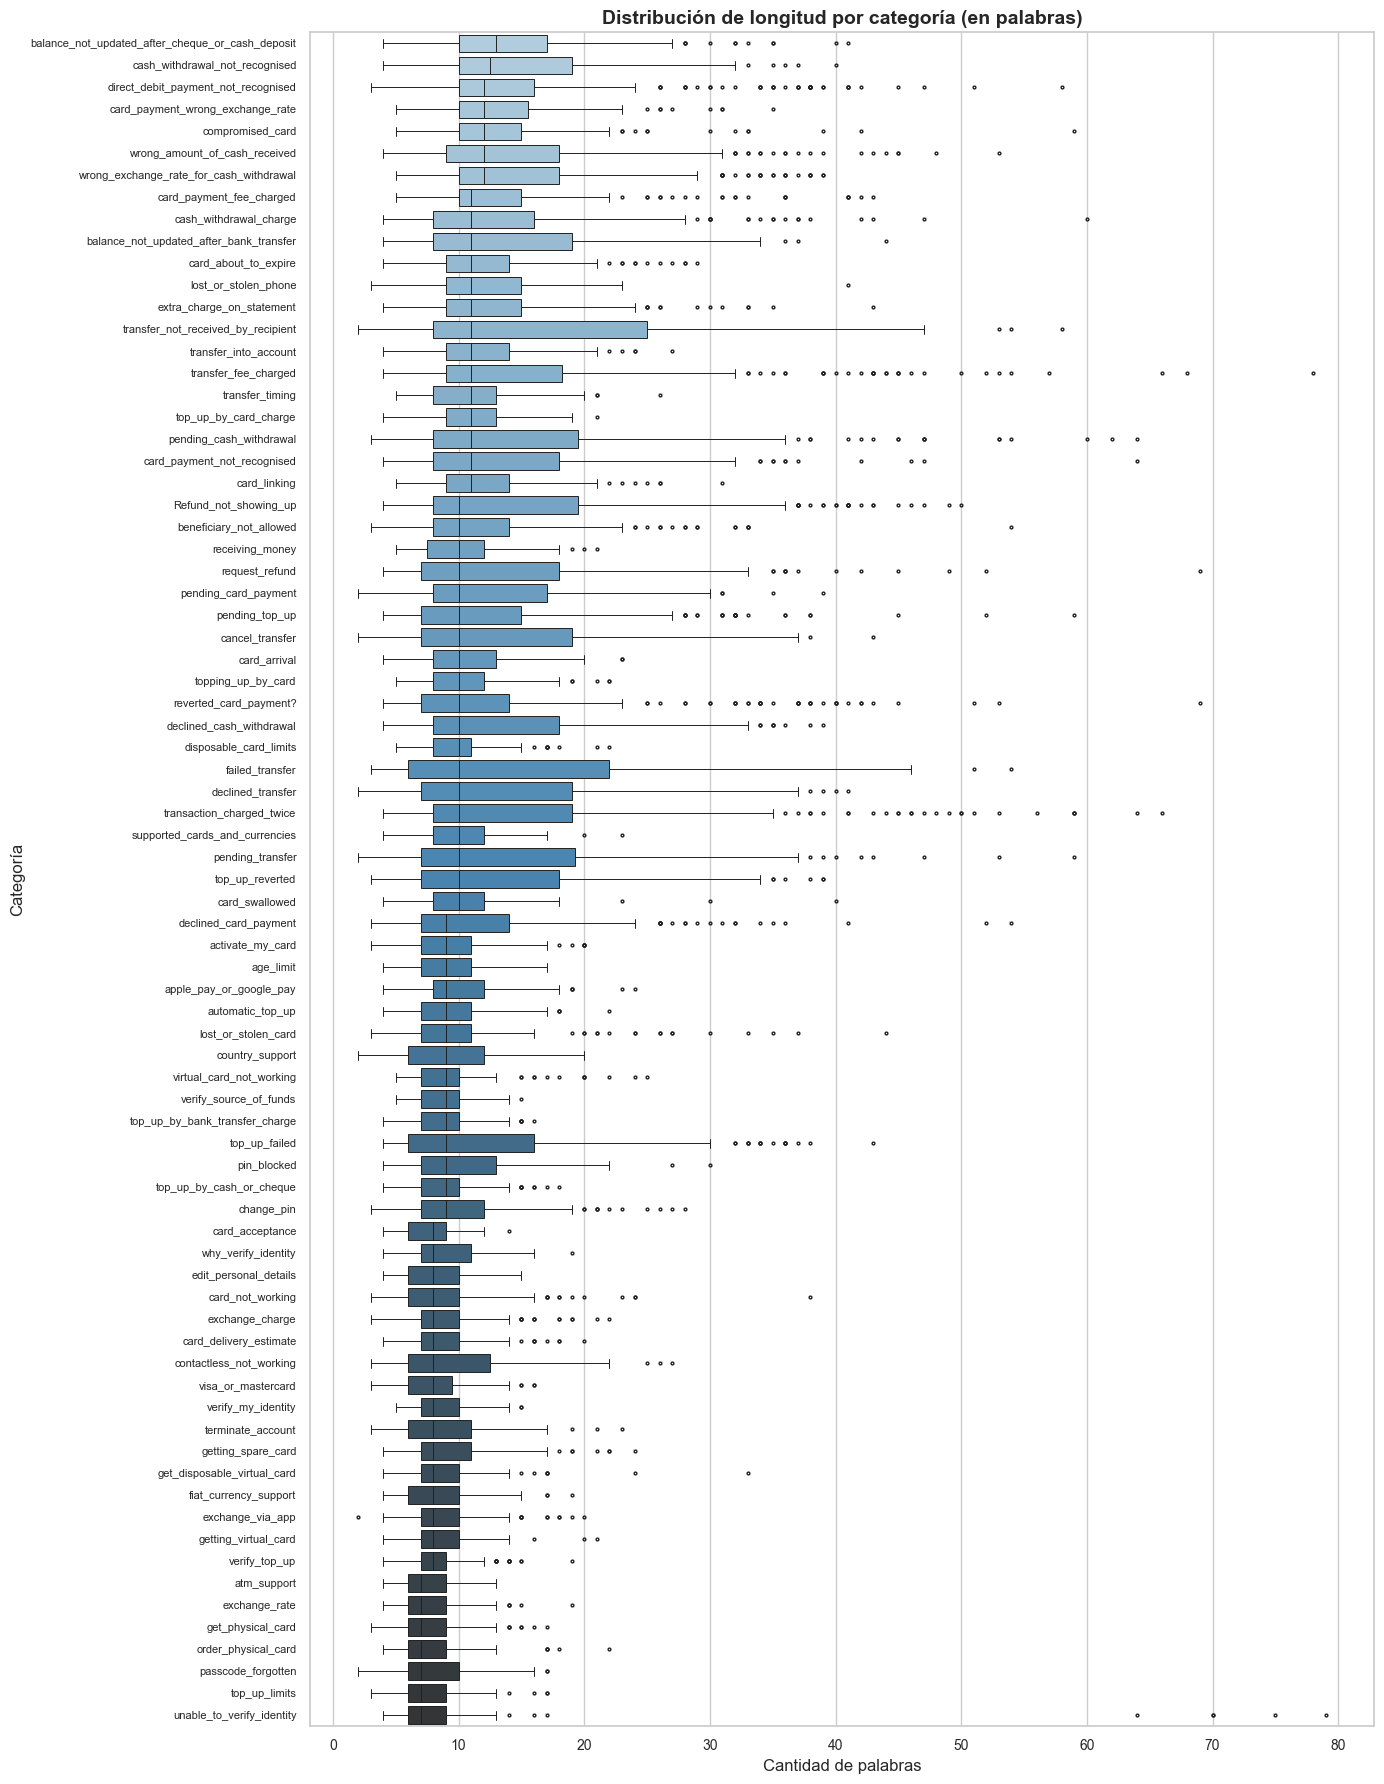

In [33]:
# Ordenamos por mediana de word_count para que sea legible
order = (df.groupby("category")["word_count"]
           .median()
           .sort_values(ascending=False)
           .index)

fig, ax = plt.subplots(figsize=(14, 18))
sns.boxplot(
    data=df,
    x="word_count",
    y="category",
    order=order,
    palette="Blues_d",
    linewidth=0.7,
    fliersize=2,
    ax=ax
)
ax.set_title("Distribución de longitud por categoría (en palabras)", fontsize=14, fontweight="bold")
ax.set_xlabel("Cantidad de palabras")
ax.set_ylabel("Categoría")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


In [34]:
# Definimos outliers como mensajes fuera de 1.5 * IQR
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)
IQR = Q3 - Q1

muy_cortos = df[df["word_count"] <= 3]
muy_largos = df[df["word_count"] > Q3 + 1.5 * IQR]

print(f"Mensajes muy cortos (≤ 3 palabras): {len(muy_cortos)} ({100*len(muy_cortos)/len(df):.2f}%)")
print(f"Mensajes muy largos (> Q3 + 1.5·IQR = {Q3 + 1.5*IQR:.0f} palabras): {len(muy_largos)} ({100*len(muy_largos)/len(df):.2f}%)")

print("\n--- Ejemplos de mensajes muy cortos ---")
print(muy_cortos[["text", "category", "word_count"]].head(10).to_string(index=False))

print("\n--- Ejemplos de mensajes muy largos ---")
print(muy_largos[["text", "category", "word_count"]].sort_values("word_count", ascending=False).head(5).to_string(index=False))


Mensajes muy cortos (≤ 3 palabras): 49 (0.37%)
Mensajes muy largos (> Q3 + 1.5·IQR = 22 palabras): 1118 (8.55%)

--- Ejemplos de mensajes muy cortos ---
                         text                category  word_count
  withdrawal pending meaning? pending_cash_withdrawal           3
Explain pending transactions. pending_cash_withdrawal           3
           Report stolen card     lost_or_stolen_card           3
         Cancel a transaction         cancel_transfer           3
         stop the transaction         cancel_transfer           3
           Cancel Transaction         cancel_transfer           2
     Cancelling a transaction         cancel_transfer           3
       Are top-ups unlimited?           top_up_limits           3
          top up cancellation         top_up_reverted           3
  Explain top-up cancellation         top_up_reverted           3

--- Ejemplos de mensajes muy largos ---
                                                                                

--- Correlaciones ---
Coeficiente de Pearson:  0.9840
Coeficiente de Spearman: 0.9423



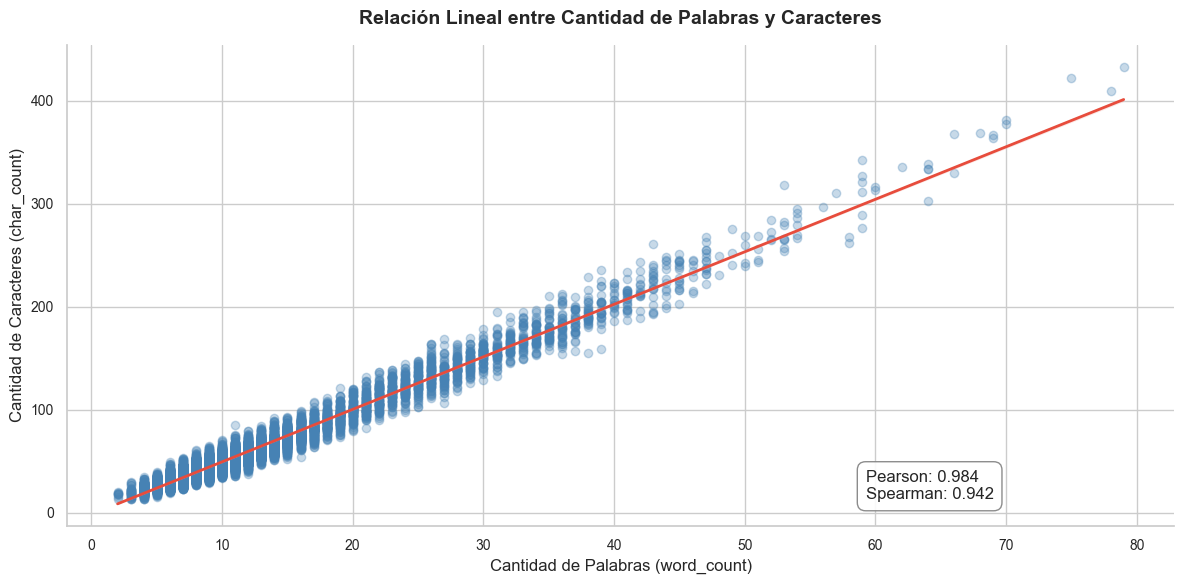

In [35]:
# ----------------------------------------------------
# Análisis: Relación lineal entre word_count y char_count
# ----------------------------------------------------
# Calculamos los coeficientes de correlación de Pearson y Spearman
corr_pearson = df['word_count'].corr(df['char_count'], method='pearson')
corr_spearman = df['word_count'].corr(df['char_count'], method='spearman')

print("--- Correlaciones ---")
print(f"Coeficiente de Pearson:  {corr_pearson:.4f}")
print(f"Coeficiente de Spearman: {corr_spearman:.4f}\n")

# Gráfico de dispersión (Scatterplot) con línea de regresión
plt.figure(figsize=(12, 6))
sns.regplot(
    data=df, 
    x="word_count", 
    y="char_count", 
    scatter_kws={"alpha": 0.3, "color": "steelblue"},
    line_kws={"color": "#e74c3c", "linewidth": 2}
)

plt.title("Relación Lineal entre Cantidad de Palabras y Caracteres", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Cantidad de Palabras (word_count)", fontsize=12)
plt.ylabel("Cantidad de Caracteres (char_count)", fontsize=12)

# Añadimos un recuadro explicativo con los coeficientes dentro del gráfico
x_pos = df['word_count'].max() * 0.75
y_pos = df['char_count'].min() or 10

plt.text(
    x=x_pos, 
    y=y_pos, 
    s=f"Pearson: {corr_pearson:.3f}\nSpearman: {corr_spearman:.3f}", 
    fontsize=12, 
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5')
)

sns.despine()
plt.tight_layout()
plt.show()

## **2. Feature Engineering: Codificación del Texto y Metadatos**
En esta sección vamos a preparar cuatro versiones distintas de nuestros datos independientes (`X`) para luego poder experimentar con los modelos:
1. **Solo TF-IDF:** Matriz dispersa tradicional que considera solo la frecuencia de las palabras.
2. **TF-IDF + Features (word_count, char_count):** Matriz dispersa híbrida utilizando `ColumnTransformer` y `StandardScaler`.
3. **Solo Embeddings:** Matriz densa pura utilizando Sentence Transformers (`X_embs_solo`).
4. **Embeddings + Features:** Matriz densa híbrida uniendo embeddings con los metadatos numéricos (`X_embs_extra`).

In [36]:
# Reemplazamos char_count por avg_word_length (captura complejidad léxica,
# información ortogonal a word_count y menos redundante)
df['avg_word_length'] = df['char_count'] / df['word_count']

In [39]:
df.head(5)

,text,category,text_clean,word_count,char_count,avg_word_length
0,I am still waiting on my card?,card_arrival,still wait card,7,30,4.285714
1,What can I do if my card still hasn't arrived ...,card_arrival,card still hasnt arrive week,13,60,4.615385
2,I have been waiting over a week. Is the card s...,card_arrival,wait week card still come,12,58,4.833333
3,Can I track my card while it is in the process...,card_arrival,track card process delivery,13,59,4.538462
4,"How do I know if I will get my card, or if it ...",card_arrival,know get card lose,15,54,3.600000


C:\Users\Gonza Gaitan\AppData\Local\Temp\ipykernel_22580\3942233916.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


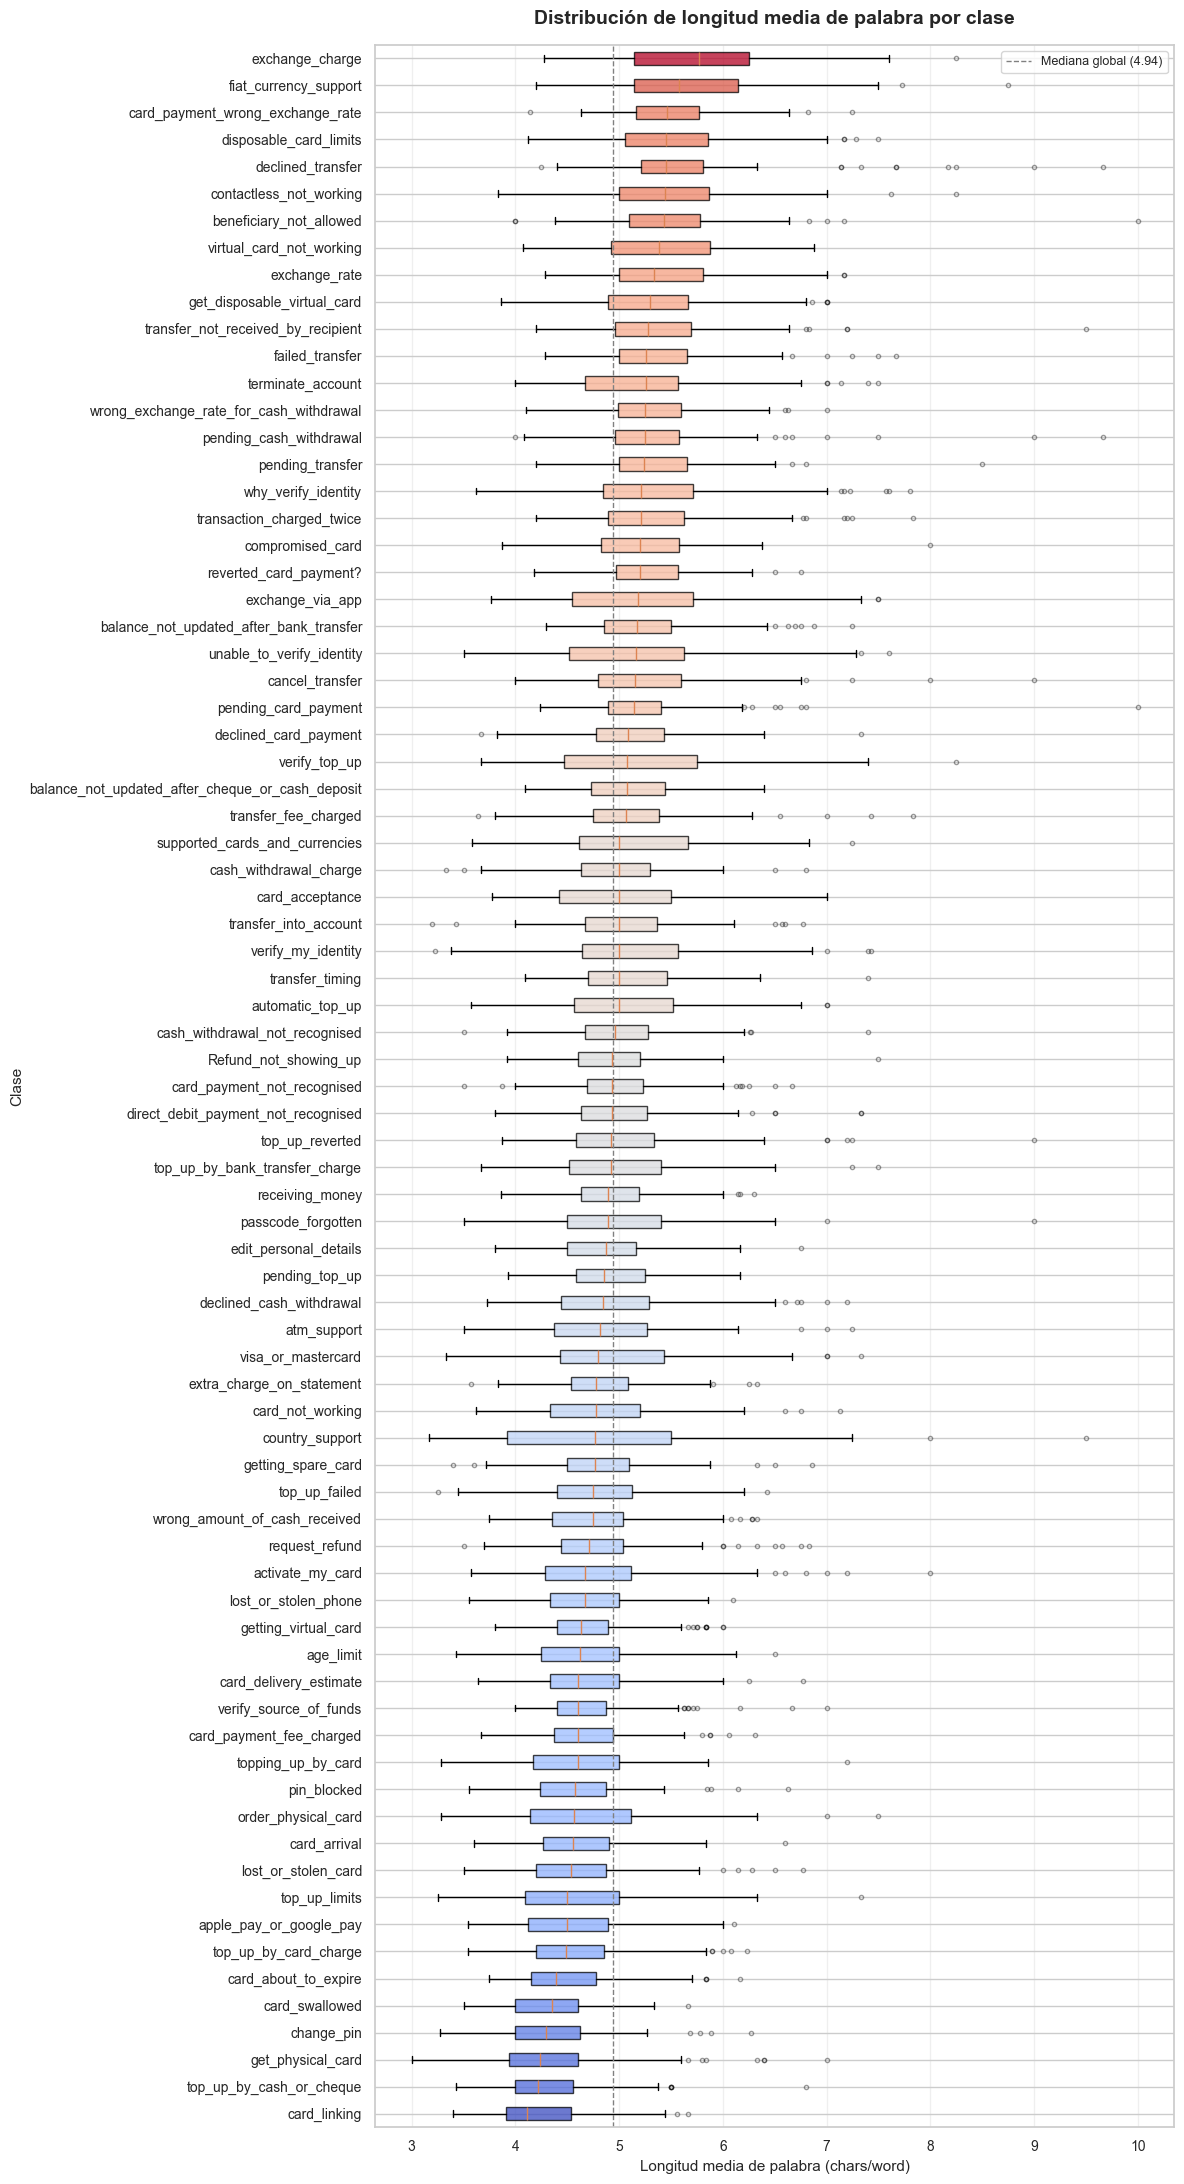

In [47]:
# Ordenar clases por mediana de avg_word_length
orden = (
    df.groupby('category')['avg_word_length']
    .median()
    .sort_values()
)

data_plot = [
    df.loc[df['category'] == clase, 'avg_word_length'].values
    for clase in orden.index
]

fig, ax = plt.subplots(figsize=(12, 22))
bp = ax.boxplot(
    data_plot,
    vert=False,
    patch_artist=True,
    labels=orden.index,
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)

# Colorear cajas con gradiente según mediana
cmap = plt.cm.coolwarm
medianas = [np.median(d) for d in data_plot]
norm = plt.Normalize(min(medianas), max(medianas))
for patch, med in zip(bp['boxes'], medianas):
    patch.set_facecolor(cmap(norm(med)))
    patch.set_alpha(0.75)

ax.set_title("Distribución de longitud media de palabra por clase", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Longitud media de palabra (chars/word)", fontsize=11)
ax.set_ylabel("Clase", fontsize=11)
ax.axvline(df['avg_word_length'].median(), color='gray', linestyle='--',
           linewidth=1, label=f"Mediana global ({df['avg_word_length'].median():.2f})")
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## División del conjunto de datos

In [55]:
# Definimos variables independientes (X) y target (y)
# Usamos el DataFrame df que ya tiene 'text', 'text_clean', 'word_count' y 'avg_word_length'
X = df[['text_clean', 'text', 'word_count', 'avg_word_length']]
y = df['category']

# 2. Hacemos el split estratificado (clave para datasets de clasificación con muchas categorías)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensiones de Train: {X_train.shape[0]} muestras")
print(f"Dimensiones de Test : {X_test.shape[0]} muestras")


Dimensiones de Train: 10466 muestras
Dimensiones de Test : 2617 muestras


## Vectorización

In [58]:
# --- Opción 1: Solo TF-IDF ---
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf_solo_train = tfidf.fit_transform(X_train['text_clean'])   # fit solo en train
X_tfidf_solo_test  = tfidf.transform(X_test['text_clean'])        # solo transform en test
print(f"1. Shape de X_tfidf_solo_train: {X_tfidf_solo_train.shape} (Matriz Dispersa)")
print(f"   Shape de X_tfidf_solo_test : {X_tfidf_solo_test.shape} (Matriz Dispersa)\n")

# --- Opción 2: TF-IDF + Extra Features ---
preprocessor_tfidf = ColumnTransformer(
    transformers=[
        ('texto',     TfidfVectorizer(max_features=5000), 'text_clean'),
        ('numericas', StandardScaler(), ['word_count', 'avg_word_length'])
    ],
    remainder='drop'
)
X_tfidf_extra_train = preprocessor_tfidf.fit_transform(X_train)  # fit solo en train
X_tfidf_extra_test  = preprocessor_tfidf.transform(X_test)       # solo transform en test
print(f"2. Shape de X_tfidf_extra_train: {X_tfidf_extra_train.shape} (Matriz Dispersa)")
print(f"   Shape de X_tfidf_extra_test : {X_tfidf_extra_test.shape} (Matriz Dispersa)\n")

# --- Opciones 3 y 4: Embeddings y Embeddings + Extra Features ---
print("Generando Embeddings...")
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')

# Opción 3: Solo Embeddings
X_embs_solo_train = model_sbert.encode(X_train['text'].tolist(), show_progress_bar=True)
X_embs_solo_test  = model_sbert.encode(X_test['text'].tolist(), show_progress_bar=True)
print(f"3. Shape de X_embs_solo_train: {X_embs_solo_train.shape} (Matriz Densa)")
print(f"   Shape de X_embs_solo_test : {X_embs_solo_test.shape} (Matriz Densa)\n")

# Escalamos las características numéricas por separado
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_train[['word_count', 'avg_word_length']])  # fit solo en train
X_num_test  = scaler.transform(X_test[['word_count', 'avg_word_length']])       # transform en test

# Opción 4: Embeddings + Extra Features
X_embs_extra_train = np.hstack((X_embs_solo_train, X_num_train))
X_embs_extra_test  = np.hstack((X_embs_solo_test, X_num_test))
print(f"4. Shape de X_embs_extra_train: {X_embs_extra_train.shape} (Matriz Densa)")
print(f"   Shape de X_embs_extra_test : {X_embs_extra_test.shape} (Matriz Densa)")


1. Shape de X_tfidf_solo_train: (10466, 1800) (Matriz Dispersa)
   Shape de X_tfidf_solo_test : (2617, 1800) (Matriz Dispersa)

2. Shape de X_tfidf_extra_train: (10466, 1802) (Matriz Dispersa)
   Shape de X_tfidf_extra_test : (2617, 1802) (Matriz Dispersa)

Generando Embeddings...


Batches: 100%|██████████| 82/82 [00:04<00:00, 17.07it/s]

3. Shape de X_embs_solo_train: (10466, 384) (Matriz Densa)
   Shape de X_embs_solo_test : (2617, 384) (Matriz Densa)

4. Shape de X_embs_extra_train: (10466, 386) (Matriz Densa)
   Shape de X_embs_extra_test : (2617, 386) (Matriz Densa)


## **3. Selección del dataset de prueba**

In [59]:
"""
Cambiar X_train_selected y X_test_selected según el dataset a probar
Opciones:
- Solo TF-IDF:        X_train_selected, X_test_selected = X_tfidf_solo_train.copy(), X_tfidf_solo_test.copy()
- TF-IDF + Extra:     X_train_selected, X_test_selected = X_tfidf_extra_train.copy(), X_tfidf_extra_test.copy()
- Solo Embeddings:    X_train_selected, X_test_selected = X_embs_solo_train.copy(), X_embs_solo_test.copy()
- Embeddings + Extra: X_train_selected, X_test_selected = X_embs_extra_train.copy(), X_embs_extra_test.copy()
"""

# Seleccionamos las variables (Ejemplo: Solo TF-IDF)
X_train_selected = X_tfidf_solo_train.copy()
X_test_selected = X_tfidf_solo_test.copy()


## **4. Preparación de la variable dependiente (`y`)**

In [60]:
# Codificamos las clases a números (0 a 76)
encoder = LabelEncoder()

# fit_transform solo en Train; transform en Test
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

print(f"Dimensiones de X Train seleccionada: {X_train_selected.shape}")
print(f"Dimensiones de X Test seleccionada : {X_test_selected.shape}")

Dimensiones de X Train seleccionada: (10466, 1800)
Dimensiones de X Test seleccionada : (2617, 1800)


## **5. División en conjunto de Entrenamiento y Prueba**

In [61]:
# Asignamos las variables finales para el entrenamiento de los modelos
X_train_final = X_train_selected
X_test_final = X_test_selected
y_train_final = y_train_encoded
y_test_final = y_test_encoded

print(f"Datos lista para modelar:")
print(f"Train: X={X_train_final.shape}, y={y_train_final.shape}")
print(f"Test : X={X_test_final.shape}, y={y_test_final.shape}")


Datos lista para modelar:
Train: X=(10466, 1800), y=(10466,)
Test : X=(2617, 1800), y=(2617,)


In [ ]:
# ----------------------------------------------------
# TODO: Entrenamiento y Evaluación de Modelos
# ----------------------------------------------------
# Combinaciones recomendadas de representación + modelo:
#
# 1. Regresión Logística
#    - Representación ideal: TF-IDF (Opciones 1 y 2) → aprovecha la dispersión eficientemente.
#    - También funciona bien con embeddings (Opciones 3 y 4).
#    - Baseline sólido y muy rápido de entrenar.
#
# 2. XGBoost
#    - Representación ideal: Embeddings (Opciones 3 y 4) → requiere matrices densas.
#    - Con TF-IDF de 5000 features es lento y generalmente no supera a modelos lineales.
#    - Captura relaciones no lineales entre dimensiones del embedding.
#
# 3. Random Forest Classifier
#    - Representación ideal: Embeddings (Opciones 3 y 4) → ídem XGBoost.
#    - Útil también para evaluar la importancia de word_count y avg_word_length.
#    - Con TF-IDF de alta dimensionalidad tiende a ser muy lento (VER SI HACER O NO).
#
# 4. MLP (Perceptrón Multicapa con PyTorch)
#    - Representación ideal: Embeddings (Opciones 3 y 4) → vectores densos de 384/386 dims.
#    - Construir con torch.nn.Module. Es la opción más potente para embeddings.
#
# Resumen de compatibilidad:
#
#   Representación       │ LogReg │ XGBoost │ RandomForest │ MLP 
#   ─────────────────────┼────────┼─────────┼──────────────┼─────
#   TF-IDF (sparse)      │  ✅    │   ⚠️    │     ⚠️      │ ⚠️  
#   Embeddings (dense)   │  ✅    │   ✅    │     ✅      │ ✅   
